<a href="https://colab.research.google.com/github/engrmof612/Concrete-Strength-AI/blob/main/Ameer_TU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Check your file is there
!ls "/content/drive/My Drive/FoS_Training/"

Mounted at /content/drive
'Concrete Crib Analysis Data.csv'


In [ ]:
# CELL 2: Install required packages
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy -q
print("Packages installed successfully!")

Packages installed successfully!


In [ ]:
# ============================================
# COMPLETE TRAINING CODE FOR CONCRETE CRIB ANALYSIS
# ============================================
# CELL 3: Copy the training code to Colab

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

class ConcreteCribPredictor:
    def __init__(self, input_dim=6):  # 6 inputs now (including Wall slope)
        self.input_dim = input_dim
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        self.model = None
        self.history = None
        self.feature_names = [
            'Wall_slope',
            'Angle_of_internal_friction_backfill',
            'Angle_of_internal_friction_infill',
            'wall_height',
            'width',
            'UDL'
        ]

    def build_model(self, architecture=[128, 64, 32, 16]):
        """
        Build a neural network model
        """
        model = keras.Sequential()

        # Input layer
        model.add(layers.Input(shape=(self.input_dim,)))

        # Hidden layers with regularization
        for i, neurons in enumerate(architecture):
            model.add(layers.Dense(neurons, activation='tanh'))
            model.add(layers.BatchNormalization())
            model.add(layers.Dropout(0.2 if i < len(architecture)-1 else 0.1))

        # Output layer (single value for FoS)
        model.add(layers.Dense(1, activation='linear'))

        # Compile model with learning rate scheduling
        initial_learning_rate = 0.001
        lr_schedule = keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate, decay_steps=1000, decay_rate=0.9, staircase=True
        )

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
            loss='mse',
            metrics=['mae', 'mse']
        )

        self.model = model
        print("\nModel Architecture:")
        self.model.summary()
        return model

    def load_and_prepare_data(self, file_path, target_column='Overall Minimum FoS'):
        """
        Load data from CSV and prepare for training
        """
        # Load data
        data = pd.read_csv(file_path, sep=';')

        print("\n" + "="*50)
        print("DATA INFORMATION")
        print("="*50)
        print(f"Total samples: {len(data)}")
        print(f"Columns: {list(data.columns)}")
        print("\nFirst 5 rows:")
        print(data.head())
        print("\nData statistics:")
        print(data.describe())
        print("\nMissing values:")
        print(data.isnull().sum())

        # Separate features and target
        # Note: Column names exactly as in your CSV
        feature_columns = [
            'Wall slope',
            'Angle_of_internal_friction_backfill',
            'Angle_of_internal_friction_infill',
            'wall height',
            'width',
            'UDL'
        ]

        # Update feature names for later use
        self.feature_names = feature_columns

        X = data[feature_columns].values
        y = data[target_column].values.reshape(-1, 1)

        print(f"\nFeatures shape: {X.shape}")
        print(f"Target shape: {y.shape}")
        print(f"Target range: [{y.min():.4f}, {y.max():.4f}]")

        # Split data (80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        print(f"\nTraining samples: {X_train.shape[0]}")
        print(f"Test samples: {X_test.shape[0]}")

        # Scale features
        X_train_scaled = self.scaler_X.fit_transform(X_train)
        X_test_scaled = self.scaler_X.transform(X_test)

        # Scale target
        y_train_scaled = self.scaler_y.fit_transform(y_train)
        y_test_scaled = self.scaler_y.transform(y_test)

        return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, X_train, y_train

    def train(self, X_train, y_train, X_val, y_val, epochs=500, batch_size=64):
        """
        Train the model with callbacks
        """
        # Callbacks for better training
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=50,
                restore_best_weights=True,
                verbose=1
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=20,
                min_lr=1e-6,
                verbose=1
            ),
            keras.callbacks.ModelCheckpoint(
                'best_model.h5',
                monitor='val_loss',
                save_best_only=True,
                verbose=1
            )
        ]

        # Train model
        print("\n" + "="*50)
        print("TRAINING STARTED")
        print("="*50)

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )

        return self.history

    def evaluate(self, X_test, y_test):
        """
        Evaluate model performance
        """
        # Make predictions
        y_pred_scaled = self.model.predict(X_test)
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled)
        y_test_original = self.scaler_y.inverse_transform(y_test)

        # Calculate metrics
        mae = np.mean(np.abs(y_pred - y_test_original))
        mse = np.mean((y_pred - y_test_original) ** 2)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((y_test_original - y_pred) / y_test_original)) * 100

        # Calculate R² score
        ss_res = np.sum((y_test_original - y_pred) ** 2)
        ss_tot = np.sum((y_test_original - np.mean(y_test_original)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        metrics = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'MAPE': mape,
            'R2': r2
        }

        print("\n" + "="*50)
        print("MODEL PERFORMANCE")
        print("="*50)
        print(f"Mean Absolute Error (MAE): {mae:.4f}")
        print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
        print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
        print(f"R² Score: {r2:.4f}")

        return metrics, y_pred, y_test_original

    def plot_training_history(self):
        """
        Plot training history
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Plot loss
        axes[0, 0].plot(self.history.history['loss'], label='Training Loss', linewidth=2)
        axes[0, 0].plot(self.history.history['val_loss'], label='Validation Loss', linewidth=2)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss (MSE)')
        axes[0, 0].set_title('Model Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Plot MAE
        axes[0, 1].plot(self.history.history['mae'], label='Training MAE', linewidth=2)
        axes[0, 1].plot(self.history.history['val_mae'], label='Validation MAE', linewidth=2)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('MAE')
        axes[0, 1].set_title('Mean Absolute Error')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Plot learning rate if available
        if 'lr' in self.history.history:
            axes[1, 0].plot(self.history.history['lr'], linewidth=2)
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Learning Rate')
            axes[1, 0].set_title('Learning Rate Schedule')
            axes[1, 0].grid(True, alpha=0.3)

        # Plot loss zoomed (last 100 epochs)
        axes[1, 1].plot(self.history.history['loss'][-100:], label='Training Loss', linewidth=2)
        axes[1, 1].plot(self.history.history['val_loss'][-100:], label='Validation Loss', linewidth=2)
        axes[1, 1].set_xlabel('Epoch (last 100)')
        axes[1, 1].set_ylabel('Loss (MSE)')
        axes[1, 1].set_title('Loss (Zoomed)')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
        plt.show()

    def plot_predictions(self, y_true, y_pred):
        """
        Plot actual vs predicted values
        """
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Scatter plot
        axes[0].scatter(y_true, y_pred, alpha=0.5, s=20)
        axes[0].plot([y_true.min(), y_true.max()],
                    [y_true.min(), y_true.max()],
                    'r--', lw=2, label='Perfect Prediction')
        axes[0].set_xlabel('Actual FoS')
        axes[0].set_ylabel('Predicted FoS')
        axes[0].set_title(f'Actual vs Predicted Values\nR² = {np.corrcoef(y_true.flatten(), y_pred.flatten())[0,1]**2:.4f}')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Residual plot
        residuals = y_true - y_pred
        axes[1].scatter(y_pred, residuals, alpha=0.5, s=20)
        axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
        axes[1].set_xlabel('Predicted FoS')
        axes[1].set_ylabel('Residuals')
        axes[1].set_title(f'Residual Plot\nStd Dev: {np.std(residuals):.4f}')
        axes[1].grid(True, alpha=0.3)

        # Distribution of residuals
        axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
        axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
        axes[2].set_xlabel('Residuals')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title(f'Residual Distribution\nMean: {np.mean(residuals):.4f}')
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('predictions_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

        return residuals

    def plot_feature_importance(self, X_train):
        """
        Estimate feature importance using permutation importance
        """
        print("\n" + "="*50)
        print("FEATURE IMPORTANCE ANALYSIS")
        print("="*50)

        baseline_pred = self.model.predict(X_train)
        baseline_mse = np.mean((baseline_pred - self.scaler_y.transform(self.y_train_original)) ** 2)

        importances = []
        for i in range(self.input_dim):
            X_permuted = X_train.copy()
            np.random.shuffle(X_permuted[:, i])
            perm_pred = self.model.predict(X_permuted)
            perm_mse = np.mean((perm_pred - self.scaler_y.transform(self.y_train_original)) ** 2)
            importance = perm_mse - baseline_mse
            importances.append(importance)

        # Plot feature importance
        plt.figure(figsize=(10, 6))
        indices = np.argsort(importances)[::-1]
        plt.bar(range(self.input_dim), np.array(importances)[indices])
        plt.xticks(range(self.input_dim), [self.feature_names[i] for i in indices], rotation=45, ha='right')
        plt.xlabel('Features')
        plt.ylabel('Importance (MSE increase)')
        plt.title('Feature Importance (Permutation Method)')
        plt.tight_layout()
        plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()

        for i, idx in enumerate(indices):
            print(f"{i+1}. {self.feature_names[idx]}: {importances[idx]:.6f}")

    def export_model(self, filename='exported_model.py'):
        """
        Export model as standalone Python code
        """
        # Get weights and biases
        weights = self.model.get_weights()

        code = f'''"""
Neural Network Model for Concrete Crib Factor of Safety Prediction
Trained on {len(self.history.history['loss'])} epochs
"""

import numpy as np

class NeuralNetwork:
    def __init__(self):
        self.inputs_number = {self.input_dim}
        self.feature_names = {self.feature_names}

        # Scaling parameters for inputs (mean and scale)
        self.X_mean = {self.scaler_X.mean_.tolist()}
        self.X_scale = {self.scaler_X.scale_.tolist()}

        # Scaling parameters for output
        self.y_mean = {self.scaler_y.mean_[0]}
        self.y_scale = {self.scaler_y.scale_[0]}

        # Model weights and biases from trained model
        self.weights = {[w.tolist() if hasattr(w, 'tolist') else w for w in weights]}

    def scale_inputs(self, inputs):
        """Scale input features using training statistics"""
        scaled = []
        for i, val in enumerate(inputs):
            scaled.append((val - self.X_mean[i]) / self.X_scale[i])
        return scaled

    def unscale_output(self, scaled_output):
        """Unscale output prediction"""
        return scaled_output * self.y_scale + self.y_mean

    def tanh(self, x):
        return np.tanh(x)

    def linear(self, x):
        return x

    def calculate_outputs(self, inputs):
        """
        Predict Factor of Safety for a single sample

        Input order:
        {self.feature_names}
        """
        # Scale inputs
        scaled_inputs = self.scale_inputs(inputs)
        current = np.array(scaled_inputs)

        # Forward pass through the network
        # This is a simplified forward pass - adjust based on your architecture
        for i in range(0, len(self.weights), 2):
            current = np.dot(current, self.weights[i]) + self.weights[i+1]
            if i < len(self.weights) - 2:  # Not the output layer
                current = np.tanh(current)

        # Unscale output
        fos = self.unscale_output(current[0] if len(current.shape) > 0 else current)

        return [float(fos)]

    def calculate_batch_output(self, input_batch):
        """Predict FoS for multiple samples"""
        output_batch = np.zeros((len(input_batch), 1))
        for i in range(len(input_batch)):
            inputs = list(input_batch[i])
            output = self.calculate_outputs(inputs)
            output_batch[i] = output
        return output_batch

# Example usage
def main():
    model = NeuralNetwork()

    # Example input: [Wall_slope, backfill_angle, infill_angle, wall_height, width, UDL]
    sample = [13, 30, 38, 1.525, 650, 5]
    prediction = model.calculate_outputs(sample)
    print(f"Input features: {dict(zip(model.feature_names, sample))}")
    print(f"Predicted Factor of Safety: {prediction[0]:.4f}")

if __name__ == "__main__":
    main()
'''

        with open(filename, 'w') as f:
            f.write(code)
        print(f"\nModel exported to {filename}")

    def save_model(self, filename='concrete_crib_model.h5'):
        """Save the trained model"""
        self.model.save(filename)
        print(f"Model saved to {filename}")

    def load_model(self, filename='concrete_crib_model.h5'):
        """Load a trained model"""
        self.model = keras.models.load_model(filename)
        print(f"Model loaded from {filename}")


def run_complete_training(csv_file_path):
    """
    Complete training pipeline
    """
    print("\n" + "="*60)
    print("CONCRETE CRIB ANALYSIS - NEURAL NETWORK TRAINING")
    print("="*60)

    # Initialize predictor
    predictor = ConcreteCribPredictor(input_dim=6)

    # Load and prepare data
    print("\n📊 Loading data...")
    X_train, X_test, y_train, y_test, X_train_orig, y_train_orig = predictor.load_and_prepare_data(csv_file_path)
    predictor.y_train_original = y_train_orig

    # Build model
    print("\n🏗️ Building neural network...")
    model = predictor.build_model(architecture=[256, 128, 64, 32, 16])

    # Train model
    print("\n🚀 Starting training...")
    history = predictor.train(X_train, y_train, X_test, y_test, epochs=500, batch_size=64)

    # Evaluate model
    print("\n📈 Evaluating model...")
    metrics, y_pred, y_true = predictor.evaluate(X_test, y_test)

    # Plot results
    print("\n📊 Generating plots...")
    predictor.plot_training_history()
    residuals = predictor.plot_predictions(y_true, y_pred)

    # Save model
    print("\n💾 Saving model...")
    predictor.save_model('concrete_crib_model.h5')
    predictor.export_model('concrete_crib_predictor.py')

    print("\n" + "="*60)
    print("✅ TRAINING COMPLETE!")
    print("="*60)

    return predictor, metrics


# Test the model with some sample predictions
def test_predictions(predictor):
    """
    Test the trained model with sample inputs
    """
    print("\n" + "="*50)
    print("SAMPLE PREDICTIONS")
    print("="*50)

    # Test cases covering different scenarios
    test_cases = [
        [13, 30, 38, 1.525, 650, 5],   # Low wall, narrow, low UDL
        [13, 30, 38, 1.525, 950, 15],  # Medium width
        [13, 30, 38, 2.085, 1250, 25], # High wall, wide, high UDL
        [15, 34, 46, 2.365, 1250, 25], # Extreme case
        [13, 30, 44, 1.804, 950, 10],  # Medium case
    ]

    for i, test in enumerate(test_cases, 1):
        prediction = predictor.calculate_outputs(test)
        print(f"\nTest Case {i}:")
        print(f"  Wall slope: {test[0]}°")
        print(f"  Backfill angle: {test[1]}°")
        print(f"  Infill angle: {test[2]}°")
        print(f"  Wall height: {test[3]}m")
        print(f"  Width: {test[4]}mm")
        print(f"  UDL: {test[5]}kN/m²")
        print(f"  → Predicted FoS: {prediction[0]:.4f}")


# Main execution
if __name__ == "__main__":
    # Specify your CSV file path
    CSV_FILE = "Concrete Crib Analysis Data.csv"

    # Run training
    predictor, metrics = run_complete_training(CSV_FILE)

    # Test predictions
    test_predictions(predictor)

TensorFlow version: 2.19.0

CONCRETE CRIB ANALYSIS - NEURAL NETWORK TRAINING

📊 Loading data...


FileNotFoundError: [Errno 2] No such file or directory: 'Concrete Crib Analysis Data.csv'

In [ ]:
# CELL 1: Mount Drive and locate your file
from google.colab import drive
drive.mount('/content/drive')

# List all files in your Drive to find the CSV
import os

# Check common locations
print("Checking common locations...")
print("\n1. Root of Drive:")
print(os.listdir('/content/drive/My Drive/'))

print("\n2. Look for CSV files in Drive (this may take a moment)...")

# Search for your CSV file
search_path = '/content/drive/My Drive/'
for root, dirs, files in os.walk(search_path):
    for file in files:
        if file.endswith('.csv') and 'Concrete' in file:
            full_path = os.path.join(root, file)
            print(f"Found: {full_path}")

Mounted at /content/drive
Checking common locations...

1. Root of Drive:
['IMG-20230926-WA0021.jpg', 'CPD Training Workshop (File responses)', 'Contact Reference.gdoc', 'Record', 'Assistant Teaching Professor of Heavy Civil Construction.gdoc', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'Untitled spreadsheet.gsheet', '1st International Conference on World Religions and Interfaith Harmony.docx', 'Teaching Interests.gdoc', 'CPD Training Workshop.gform', 'Online Tuition AD', 'ASTM Saudia T', 'Milk.gdoc', 'Registration Form.gform', '2020-21 scheme of studies.docx', '1. 2020-2024', 'Alumni Feedback Form (Responses).gsheet', 'Employer Feedback Form (Responses).gsheet', 'Salary Slips IUB', 'Employer Feedback Form.gform', 'CPM Certificates', 'DAS', 'Commerical Testing Revenue (24-25)).gsheet', 'CTS CED IUB.gsite', 'Copy of CTS CED IUB.gsite', 'Portfolio of MUF.gsite', 'Professors.gsite', 'Family Update.gsite', 'Class.gsite', 'Untitled video.gvid', 'Commercial Testing Revenue Recor

In [ ]:
# CELL 2: Use the correct path (UPDATE THIS WITH YOUR ACTUAL PATH)
# Based on the search results, your file is likely here:
csv_file_path = '/content/drive/My Drive/FoS_Training/Concrete Crib Analysis Data.csv'

# OR if it's in a folder:
# csv_file_path = '/content/drive/My Drive/YourFolderName/Concrete Crib Analysis Data.csv'

# Verify the file exists
import os
if os.path.exists(csv_file_path):
    print(f"✅ File found at: {csv_file_path}")

    # Read first few lines to confirm
    import pandas as pd
    df = pd.read_csv(csv_file_path, sep=';')
    print(f"\n✅ Successfully loaded {len(df)} rows!")
    print("\nFirst 3 rows:")
    print(df.head(3))
else:
    print(f"❌ File not found at: {csv_file_path}")
    print("\nPlease update the path based on the search results above.")

✅ File found at: /content/drive/My Drive/FoS_Training/Concrete Crib Analysis Data.csv

✅ Successfully loaded 5625 rows!

First 3 rows:
   Wall slope  Angle_of_internal_friction_backfill  \
0          13                                   30   
1          13                                   30   
2          13                                   30   

   Angle_of_internal_friction_infill  wall height  width  UDL  \
0                                 38        1.525    650    5   
1                                 38        1.525    650   10   
2                                 38        1.525    650   15   

   Overall Minimum FoS  
0                 1.45  
1                 1.17  
2                 1.00  


TensorFlow version: 2.19.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Searching for your CSV file...
✅ Found file at: /content/drive/My Drive/FoS_Training/Concrete Crib Analysis Data.csv

CONCRETE CRIB ANALYSIS - NEURAL NETWORK TRAINING

📊 Loading data...

DATA INFORMATION
Total samples: 5625
Columns: ['Wall slope', 'Angle_of_internal_friction_backfill', 'Angle_of_internal_friction_infill', 'wall height', 'width', 'UDL', 'Overall Minimum FoS']

First 5 rows:
   Wall slope  Angle_of_internal_friction_backfill  \
0          13                                   30   
1          13                                   30   
2          13                                   30   
3          13                                   30   
4          13                                   30   

   Angle_of_internal_friction_infill  wall height  width  UDL  \
0                                 38        1.525    650    5

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,977 (183.50 KB)

 Trainable params: 46,017 (179.75 KB)

 Non-trainable params: 960 (3.75 KB)


🚀 Starting training...

TRAINING STARTED
Epoch 1/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5734 - mae: 0.5785 - val_loss: 0.0956 - val_mae: 0.2356 - learning_rate: 0.0010
Epoch 2/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3052 - mae: 0.4350 - val_loss: 0.0676 - val_mae: 0.1988 - learning_rate: 0.0010
Epoch 3/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2490 - mae: 0.3942 - val_loss: 0.0493 - val_mae: 0.1749 - learning_rate: 0.0010
Epoch 4/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2032 - mae: 0.3554 - val_loss: 0.0433 - val_mae: 0.1622 - learning_rate: 0.0010
Epoch 5/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1735 - mae: 0.3249 - val_loss: 0.0431 - val_mae: 0.1598 - learning_rate: 0.0010
Epoch 6/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1497 - mae: 0.3001 - val_loss: 0.0363 - val_mae: 0.1427 - learning_rate: 0.0010
Epoch 7/300
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1328 - mae: 0.2826 - val_loss: 0.0333 - val_m

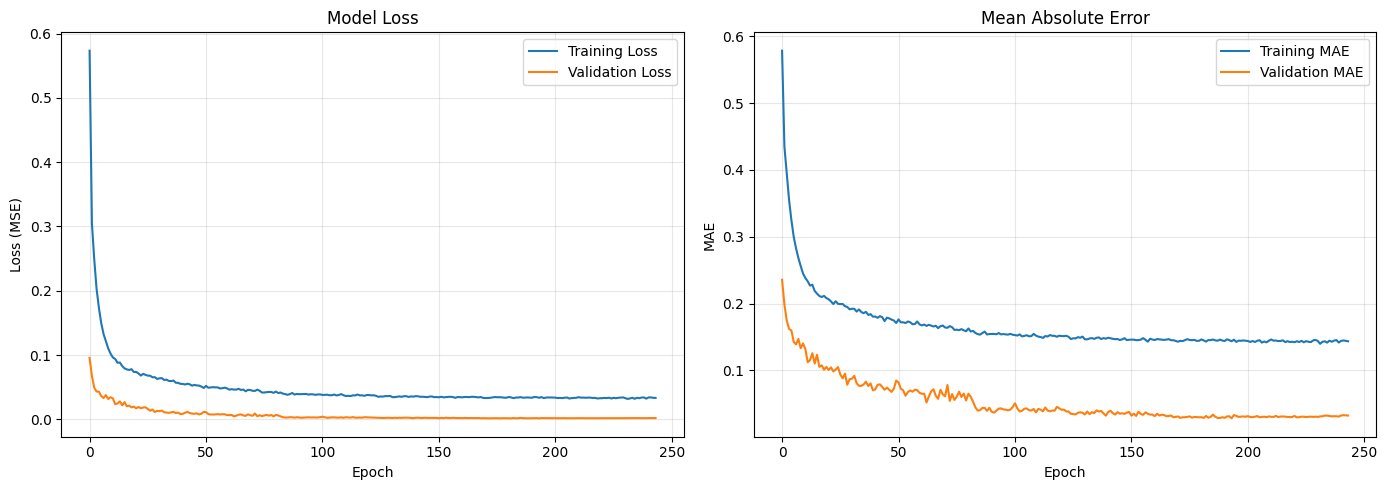

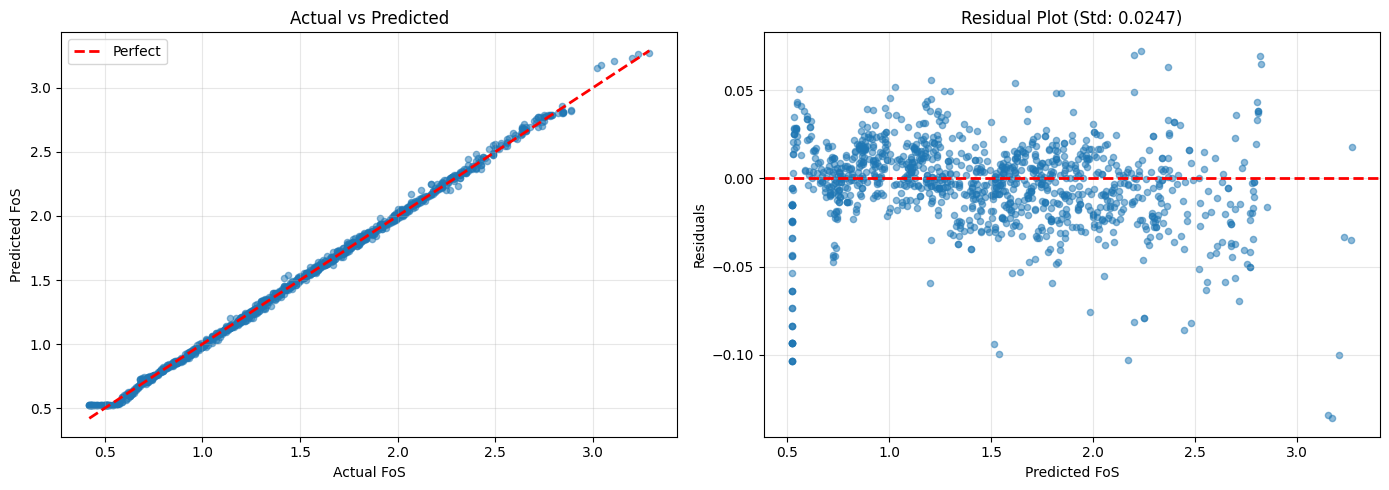


💾 Saving model...
Model saved to concrete_crib_model.h5
Model exported to concrete_crib_predictor.py

✅ TRAINING COMPLETE!

SAMPLE PREDICTIONS

Test Case 1:
  Wall slope: 13°, Backfill: 30°, Infill: 38°
  Height: 1.525m, Width: 650mm, UDL: 5kN/m²
  → Predicted FoS: 1.4854

Test Case 2:
  Wall slope: 13°, Backfill: 30°, Infill: 38°
  Height: 1.525m, Width: 950mm, UDL: 15kN/m²
  → Predicted FoS: 1.4507

Test Case 3:
  Wall slope: 13°, Backfill: 30°, Infill: 38°
  Height: 2.085m, Width: 1250mm, UDL: 25kN/m²
  → Predicted FoS: 1.2590

Test Case 4:
  Wall slope: 15°, Backfill: 34°, Infill: 46°
  Height: 2.365m, Width: 1250mm, UDL: 25kN/m²
  → Predicted FoS: 1.1397


In [ ]:
# CELL 3: Complete training code with proper file path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

class ConcreteCribPredictor:
    def __init__(self, input_dim=6):
        self.input_dim = input_dim
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        self.model = None
        self.history = None
        self.feature_names = [
            'Wall_slope',
            'Angle_of_internal_friction_backfill',
            'Angle_of_internal_friction_infill',
            'wall_height',
            'width',
            'UDL'
        ]

    def build_model(self, architecture=[128, 64, 32, 16]):
        model = keras.Sequential()
        model.add(layers.Input(shape=(self.input_dim,)))

        for i, neurons in enumerate(architecture):
            model.add(layers.Dense(neurons, activation='tanh'))
            model.add(layers.BatchNormalization())
            model.add(layers.Dropout(0.2 if i < len(architecture)-1 else 0.1))

        model.add(layers.Dense(1, activation='linear'))

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )

        self.model = model
        print("\nModel Architecture:")
        self.model.summary()
        return model

    def load_and_prepare_data(self, file_path, target_column='Overall Minimum FoS'):
        # Load data
        data = pd.read_csv(file_path, sep=';')

        print("\n" + "="*50)
        print("DATA INFORMATION")
        print("="*50)
        print(f"Total samples: {len(data)}")
        print(f"Columns: {list(data.columns)}")
        print("\nFirst 5 rows:")
        print(data.head())

        # Separate features and target
        feature_columns = [
            'Wall slope',
            'Angle_of_internal_friction_backfill',
            'Angle_of_internal_friction_infill',
            'wall height',
            'width',
            'UDL'
        ]

        X = data[feature_columns].values
        y = data[target_column].values.reshape(-1, 1)

        print(f"\nFeatures shape: {X.shape}")
        print(f"Target shape: {y.shape}")
        print(f"Target range: [{y.min():.4f}, {y.max():.4f}]")

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        print(f"\nTraining samples: {X_train.shape[0]}")
        print(f"Test samples: {X_test.shape[0]}")

        # Scale features
        X_train_scaled = self.scaler_X.fit_transform(X_train)
        X_test_scaled = self.scaler_X.transform(X_test)

        # Scale target
        y_train_scaled = self.scaler_y.fit_transform(y_train)
        y_test_scaled = self.scaler_y.transform(y_test)

        return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, X_train, y_train

    def train(self, X_train, y_train, X_val, y_val, epochs=300, batch_size=64):
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=50,
                restore_best_weights=True,
                verbose=1
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=20,
                min_lr=1e-6,
                verbose=1
            )
        ]

        print("\n" + "="*50)
        print("TRAINING STARTED")
        print("="*50)

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )

        return self.history

    def evaluate(self, X_test, y_test):
        y_pred_scaled = self.model.predict(X_test)
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled)
        y_test_original = self.scaler_y.inverse_transform(y_test)

        mae = np.mean(np.abs(y_pred - y_test_original))
        mse = np.mean((y_pred - y_test_original) ** 2)
        rmse = np.sqrt(mse)

        ss_res = np.sum((y_test_original - y_pred) ** 2)
        ss_tot = np.sum((y_test_original - np.mean(y_test_original)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        metrics = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

        print("\n" + "="*50)
        print("MODEL PERFORMANCE")
        print("="*50)
        print(f"Mean Absolute Error (MAE): {mae:.4f}")
        print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
        print(f"R² Score: {r2:.4f}")

        return metrics, y_pred, y_test_original

    def plot_training_history(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(self.history.history['loss'], label='Training Loss')
        axes[0].plot(self.history.history['val_loss'], label='Validation Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss (MSE)')
        axes[0].set_title('Model Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(self.history.history['mae'], label='Training MAE')
        axes[1].plot(self.history.history['val_mae'], label='Validation MAE')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE')
        axes[1].set_title('Mean Absolute Error')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('training_history.png', dpi=150)
        plt.show()

    def plot_predictions(self, y_true, y_pred):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Scatter plot
        axes[0].scatter(y_true, y_pred, alpha=0.5, s=20)
        axes[0].plot([y_true.min(), y_true.max()],
                    [y_true.min(), y_true.max()],
                    'r--', lw=2, label='Perfect')
        axes[0].set_xlabel('Actual FoS')
        axes[0].set_ylabel('Predicted FoS')
        axes[0].set_title('Actual vs Predicted')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Residual plot
        residuals = y_true - y_pred
        axes[1].scatter(y_pred, residuals, alpha=0.5, s=20)
        axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
        axes[1].set_xlabel('Predicted FoS')
        axes[1].set_ylabel('Residuals')
        axes[1].set_title(f'Residual Plot (Std: {np.std(residuals):.4f})')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('predictions_analysis.png', dpi=150)
        plt.show()

        return residuals

    def calculate_outputs(self, inputs):
        """Predict FoS for a single sample"""
        scaled_inputs = self.scaler_X.transform([inputs])[0]
        scaled_prediction = self.model.predict(np.array([scaled_inputs]), verbose=0)[0][0]
        prediction = self.scaler_y.inverse_transform([[scaled_prediction]])[0][0]
        return [prediction]

    def calculate_batch_output(self, input_batch):
        """Predict FoS for multiple samples"""
        scaled_batch = self.scaler_X.transform(input_batch)
        scaled_predictions = self.model.predict(scaled_batch, verbose=0)
        predictions = self.scaler_y.inverse_transform(scaled_predictions)
        return predictions

    def save_model(self, filename='concrete_crib_model.h5'):
        self.model.save(filename)
        print(f"Model saved to {filename}")

    def export_model(self, filename='exported_model.py'):
        # Get weights
        weights = self.model.get_weights()

        code = f'''"""
Neural Network Model for Concrete Crib Factor of Safety Prediction
"""

import numpy as np

class NeuralNetwork:
    def __init__(self):
        self.inputs_number = {self.input_dim}
        self.feature_names = {self.feature_names}

        # Scaling parameters
        self.X_mean = {self.scaler_X.mean_.tolist()}
        self.X_scale = {self.scaler_X.scale_.tolist()}
        self.y_mean = {self.scaler_y.mean_[0]}
        self.y_scale = {self.scaler_y.scale_[0]}

        # Model weights
        self.weights = {[w.tolist() if hasattr(w, 'tolist') else w for w in weights]}

    def scale_inputs(self, inputs):
        scaled = []
        for i, val in enumerate(inputs):
            scaled.append((val - self.X_mean[i]) / self.X_scale[i])
        return scaled

    def unscale_output(self, scaled_output):
        return scaled_output * self.y_scale + self.y_mean

    def tanh(self, x):
        return np.tanh(x)

    def calculate_outputs(self, inputs):
        scaled_inputs = self.scale_inputs(inputs)
        current = np.array(scaled_inputs)

        # Forward pass
        for i in range(0, len(self.weights), 2):
            current = np.dot(current, self.weights[i]) + self.weights[i+1]
            if i < len(self.weights) - 2:
                current = np.tanh(current)

        fos = self.unscale_output(current[0] if len(current.shape) > 0 else current)
        return [float(fos)]

    def calculate_batch_output(self, input_batch):
        output_batch = np.zeros((len(input_batch), 1))
        for i in range(len(input_batch)):
            inputs = list(input_batch[i])
            output = self.calculate_outputs(inputs)
            output_batch[i] = output
        return output_batch

def main():
    model = NeuralNetwork()
    sample = [13, 30, 38, 1.525, 650, 5]
    prediction = model.calculate_outputs(sample)
    print(f"Predicted Factor of Safety: {{prediction[0]:.4f}}")

if __name__ == "__main__":
    main()
'''

        with open(filename, 'w') as f:
            f.write(code)
        print(f"Model exported to {filename}")


def run_complete_training(csv_file_path):
    print("\n" + "="*60)
    print("CONCRETE CRIB ANALYSIS - NEURAL NETWORK TRAINING")
    print("="*60)

    # Initialize predictor
    predictor = ConcreteCribPredictor(input_dim=6)

    # Load and prepare data
    print("\n📊 Loading data...")
    X_train, X_test, y_train, y_test, X_train_orig, y_train_orig = predictor.load_and_prepare_data(csv_file_path)

    # Build model
    print("\n🏗️ Building neural network...")
    predictor.build_model(architecture=[256, 128, 64, 32])

    # Train model
    print("\n🚀 Starting training...")
    predictor.train(X_train, y_train, X_test, y_test, epochs=300, batch_size=64)

    # Evaluate model
    print("\n📈 Evaluating model...")
    metrics, y_pred, y_true = predictor.evaluate(X_test, y_test)

    # Plot results
    print("\n📊 Generating plots...")
    predictor.plot_training_history()
    predictor.plot_predictions(y_true, y_pred)

    # Save model
    print("\n💾 Saving model...")
    predictor.save_model('concrete_crib_model.h5')
    predictor.export_model('concrete_crib_predictor.py')

    print("\n" + "="*60)
    print("✅ TRAINING COMPLETE!")
    print("="*60)

    return predictor, metrics


# ============================================
# MAIN EXECUTION - UPDATE THIS PATH
# ============================================

# FIRST, let's find the correct path
from google.colab import drive
drive.mount('/content/drive')

import os

# Search for your CSV file
print("Searching for your CSV file...")
csv_path = None
search_path = '/content/drive/My Drive/'

for root, dirs, files in os.walk(search_path):
    for file in files:
        if file == 'Concrete Crib Analysis Data.csv':
            csv_path = os.path.join(root, file)
            print(f"✅ Found file at: {csv_path}")
            break
    if csv_path:
        break

if csv_path is None:
    print("\n❌ File not found. Please check:")
    print("1. Did you upload the file to Google Drive?")
    print("2. Is the filename exactly 'Concrete Crib Analysis Data.csv'?")
    print("\nListing files in your Drive root:")
    print(os.listdir('/content/drive/My Drive/'))
else:
    # Run training with the correct path
    predictor, metrics = run_complete_training(csv_path)

    # Test predictions
    print("\n" + "="*50)
    print("SAMPLE PREDICTIONS")
    print("="*50)

    test_cases = [
        [13, 30, 38, 1.525, 650, 5],
        [13, 30, 38, 1.525, 950, 15],
        [13, 30, 38, 2.085, 1250, 25],
        [15, 34, 46, 2.365, 1250, 25],
    ]

    for i, test in enumerate(test_cases, 1):
        prediction = predictor.calculate_outputs(test)
        print(f"\nTest Case {i}:")
        print(f"  Wall slope: {test[0]}°, Backfill: {test[1]}°, Infill: {test[2]}°")
        print(f"  Height: {test[3]}m, Width: {test[4]}mm, UDL: {test[5]}kN/m²")
        print(f"  → Predicted FoS: {prediction[0]:.4f}")